# 05. Risk Spillover Network Comparison (TGN · GARCH · TENET)

사례 시점(2020-03-06, 2020-03-12, 2025-04-10)에서 중심 노드 기준 상위 10개 전이 경로를 세 방법으로 비교합니다.


In [ ]:
!pip install torch_geometric
!pip install pyinform

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 23.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.2/131.2 kB 3.8 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ 구글 드라이브 마운트 완료
[중복 스킵/overwrite] gold: /content/drive/MyDrive/Find-A final/commodities/gold.csv
Nodes: 32 ['xlk', 'xlf', 'xlv', 'xly', 'xle', 'vnq', 'gold', 'move', 'vix', 'vxn', 'vxd', 'rvx', 'gvz', 'ovx', 'v2tx', 'jniv', 'stoxx50', 'nikkei225', 'shanghai', 'hangseng', 'dxy', 'rates', 'inflation_be5y', 'oil_wti', 'natgas', 'silver', 'copper', 'corn', 'wheat', 'soybean', 'coffee', 'cotton']
Return history: (4280, 32) 2010-01-04 00:00:00 ~ 2026-05-29 00:00:00
All-node returns used for GARCH/TENET: (4217, 32)
GARCH fitted: xlk
GARCH fitted: xlf
GARCH fitted: xlv
GARCH fitted: xly
GARCH fitted: xle
GARCH fitted: vnq
GARCH fitted: gold
GARCH fitted: move
GARCH fitted: vix
GARCH fitted: vxn
GARCH fitted: vxd
GARCH fitted: rvx
GARCH fitted: gvz
GARCH fitted: ovx
GARCH fitted: v2tx
GARCH fitted: jniv
GARCH fitted: stoxx50
GARCH fitted: nikkei225
GARCH fitted: shan

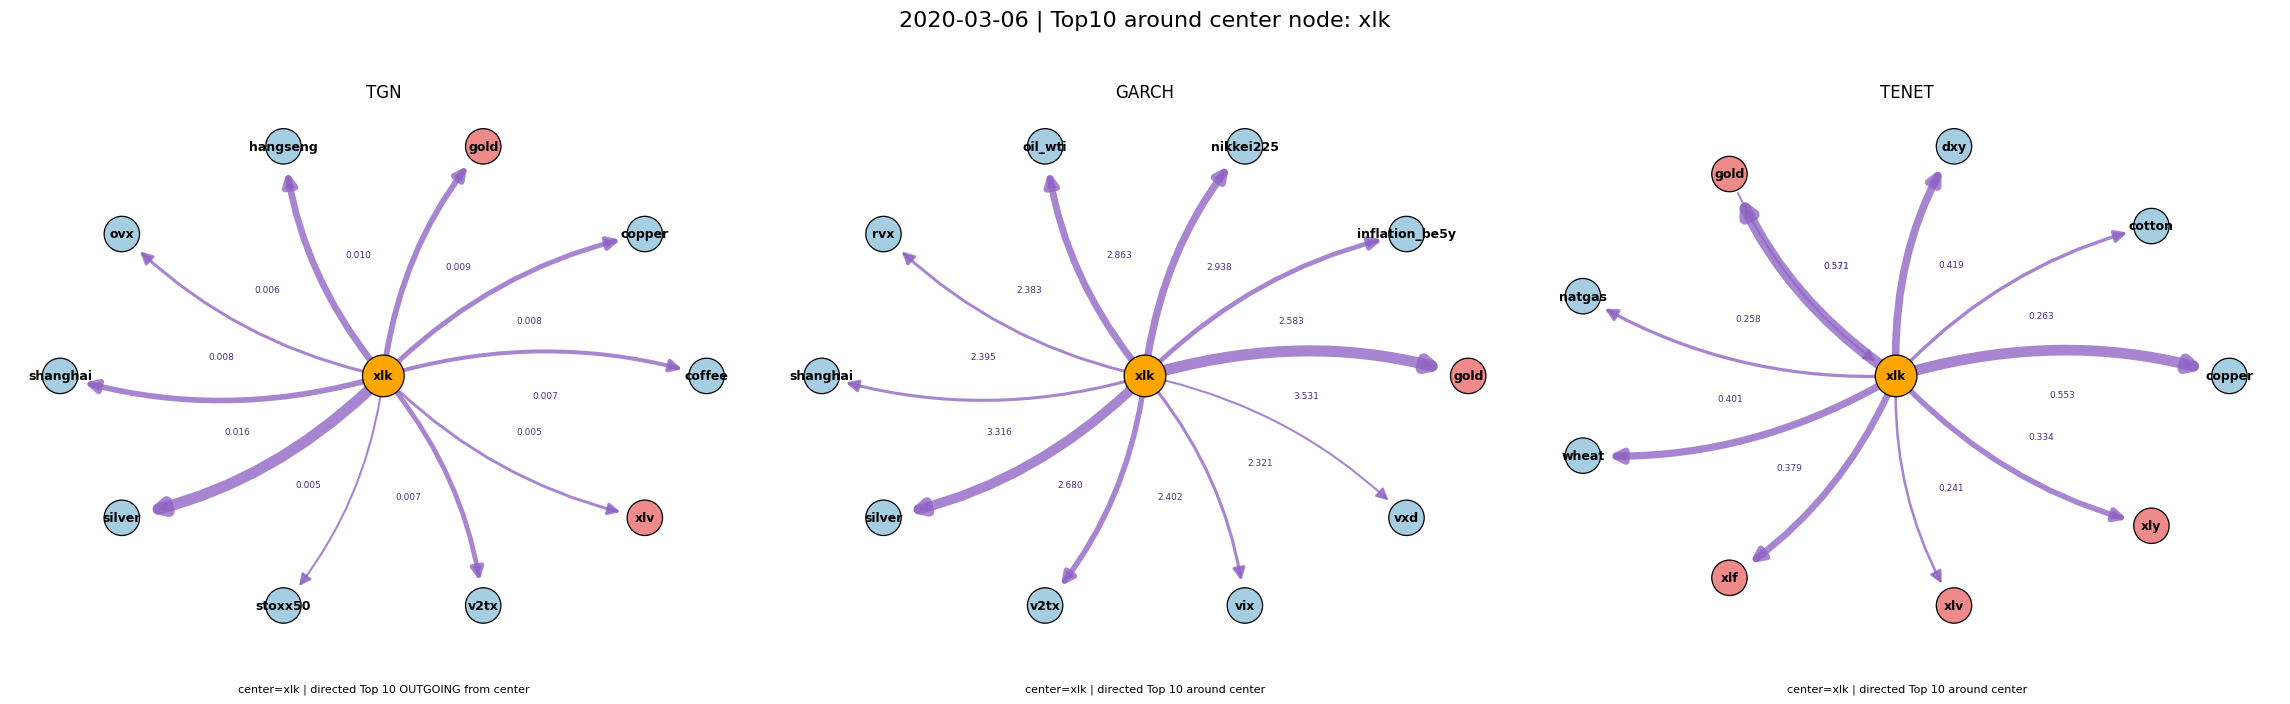

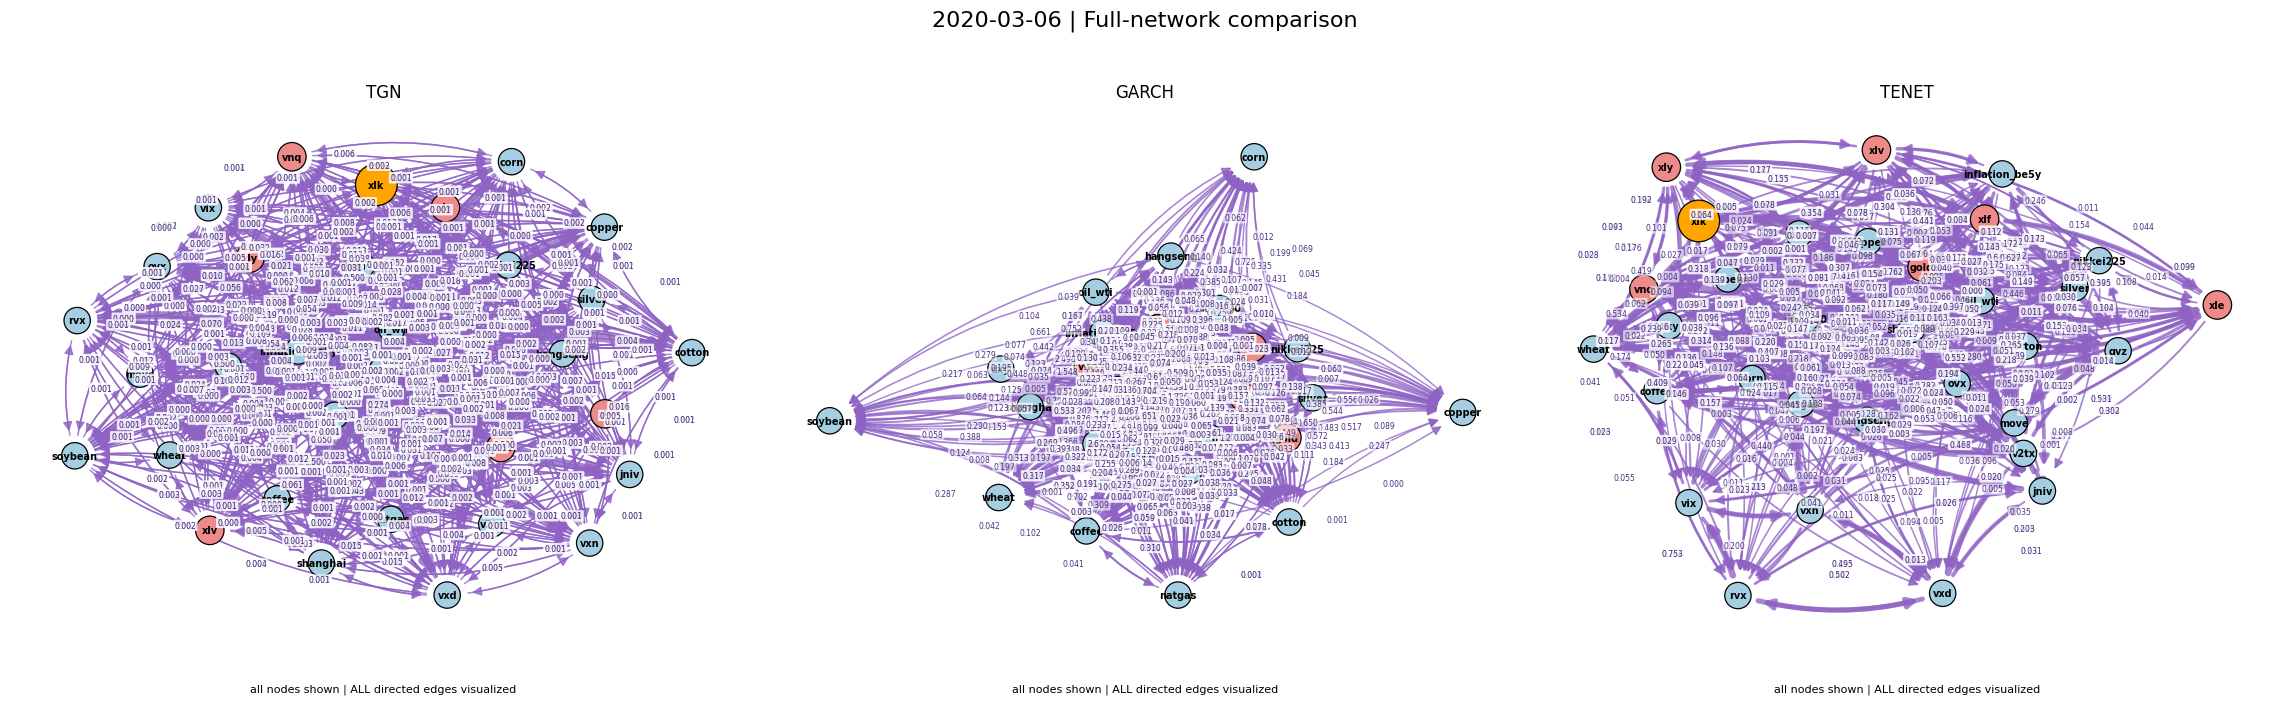


snapshot: 2020-03-12 center: inflation_be5y


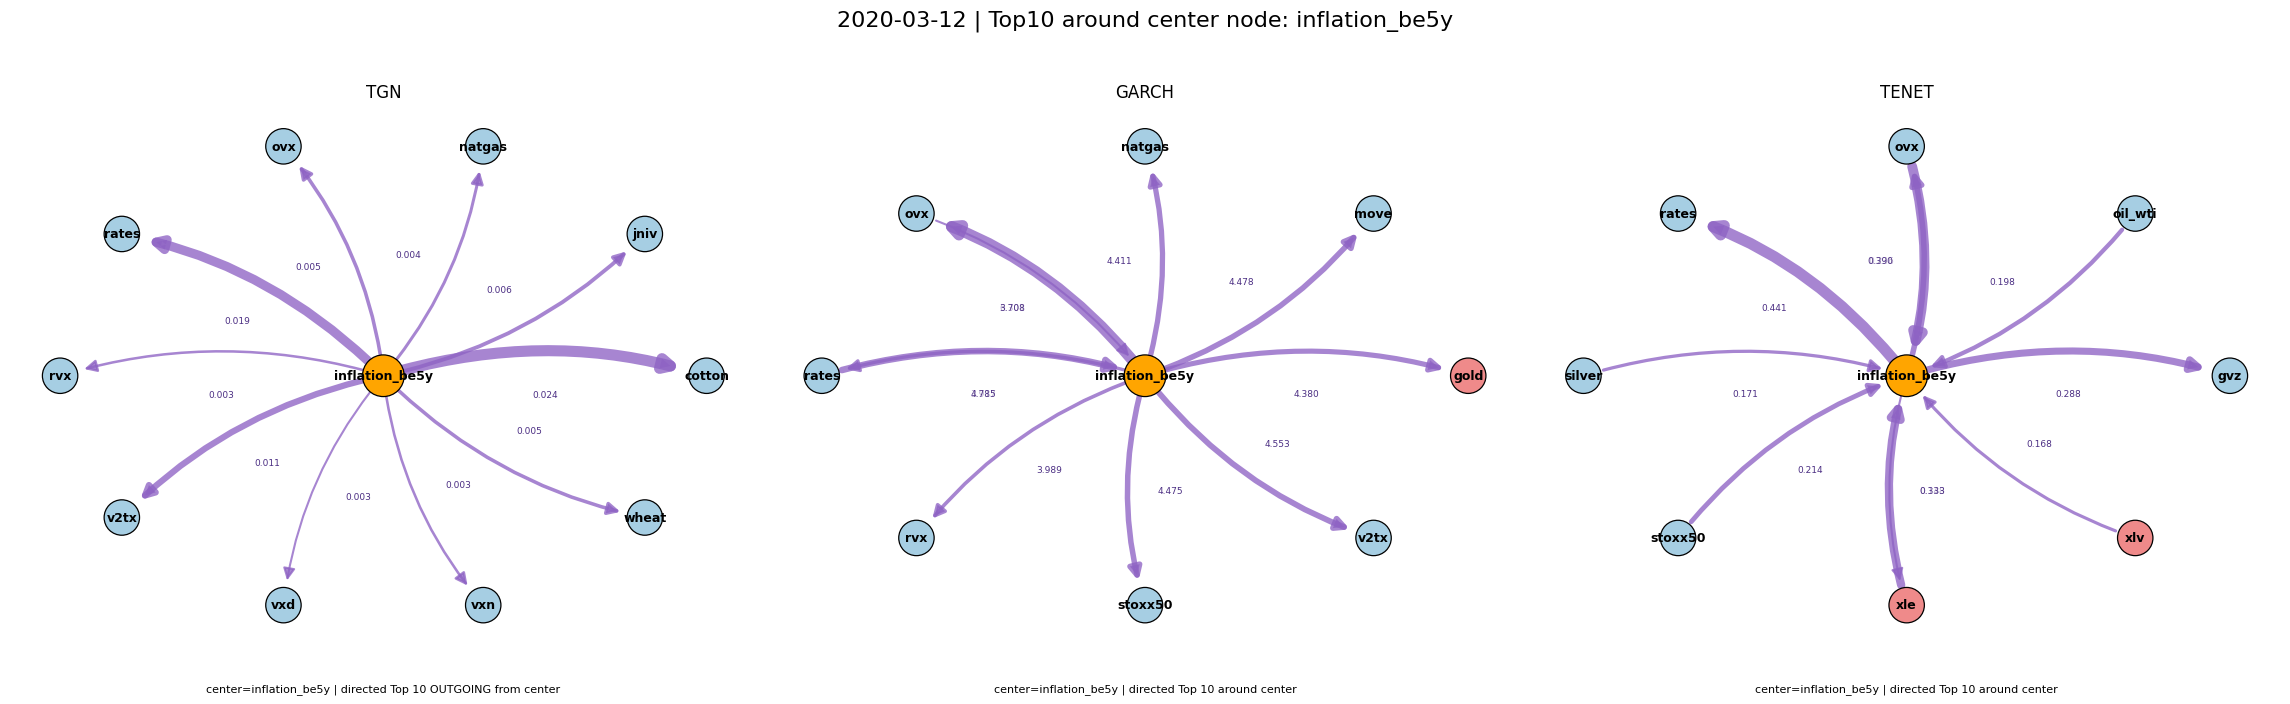

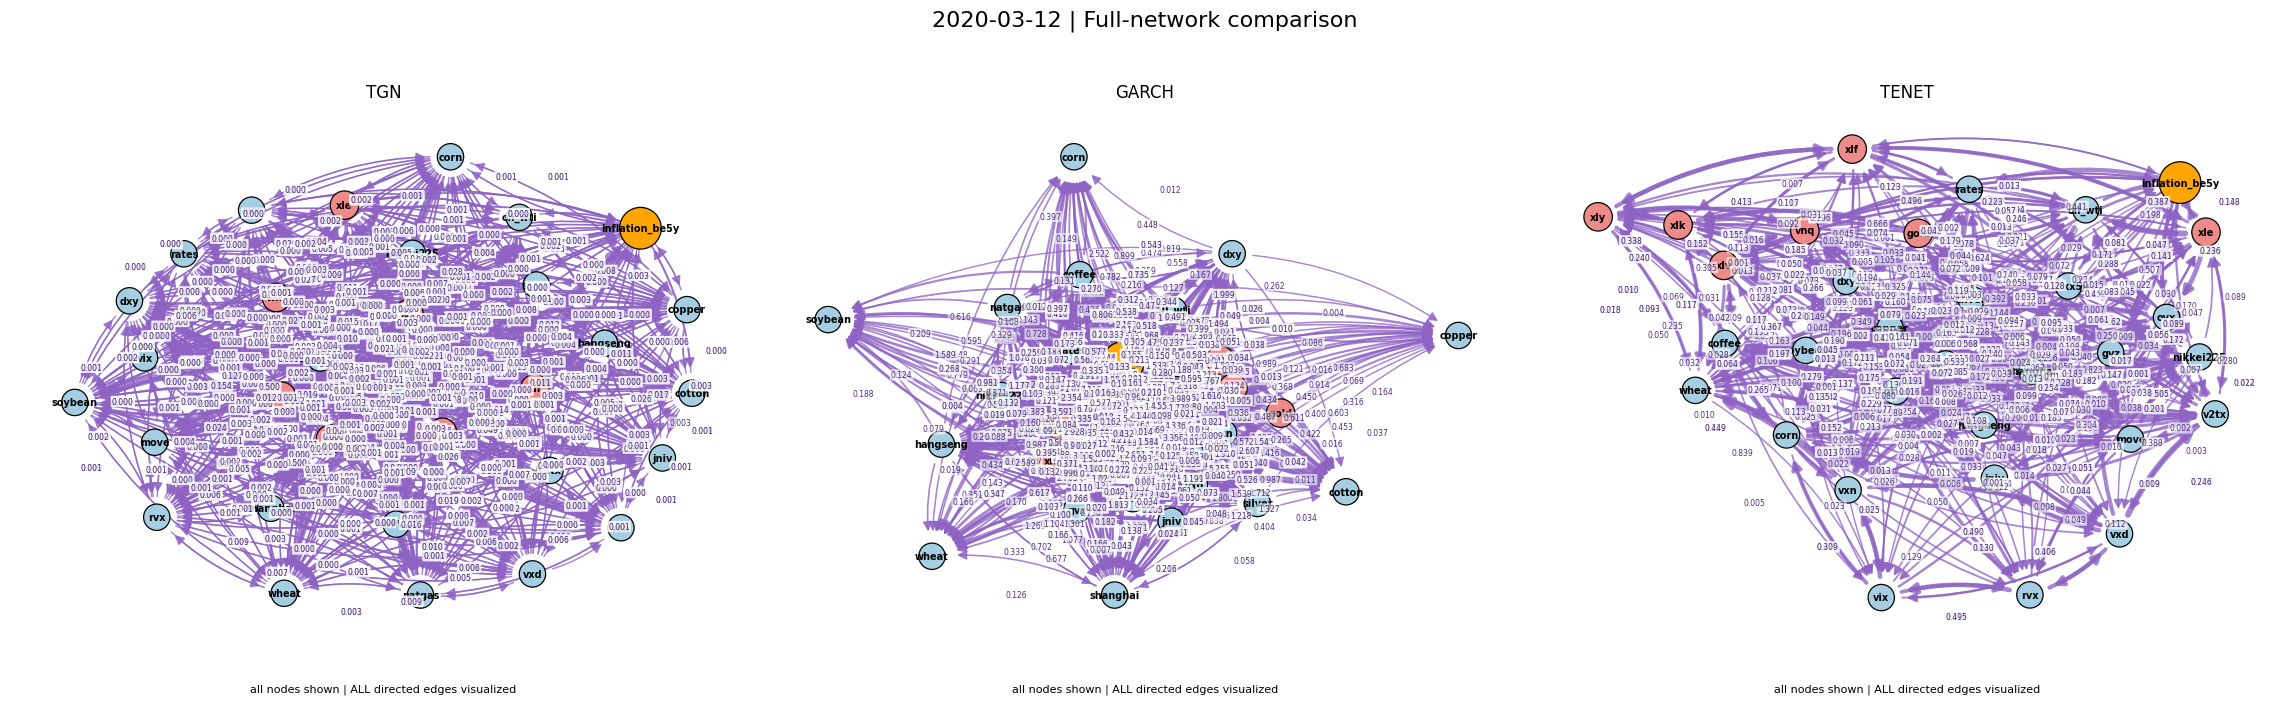


snapshot: 2025-04-10 center: nikkei225


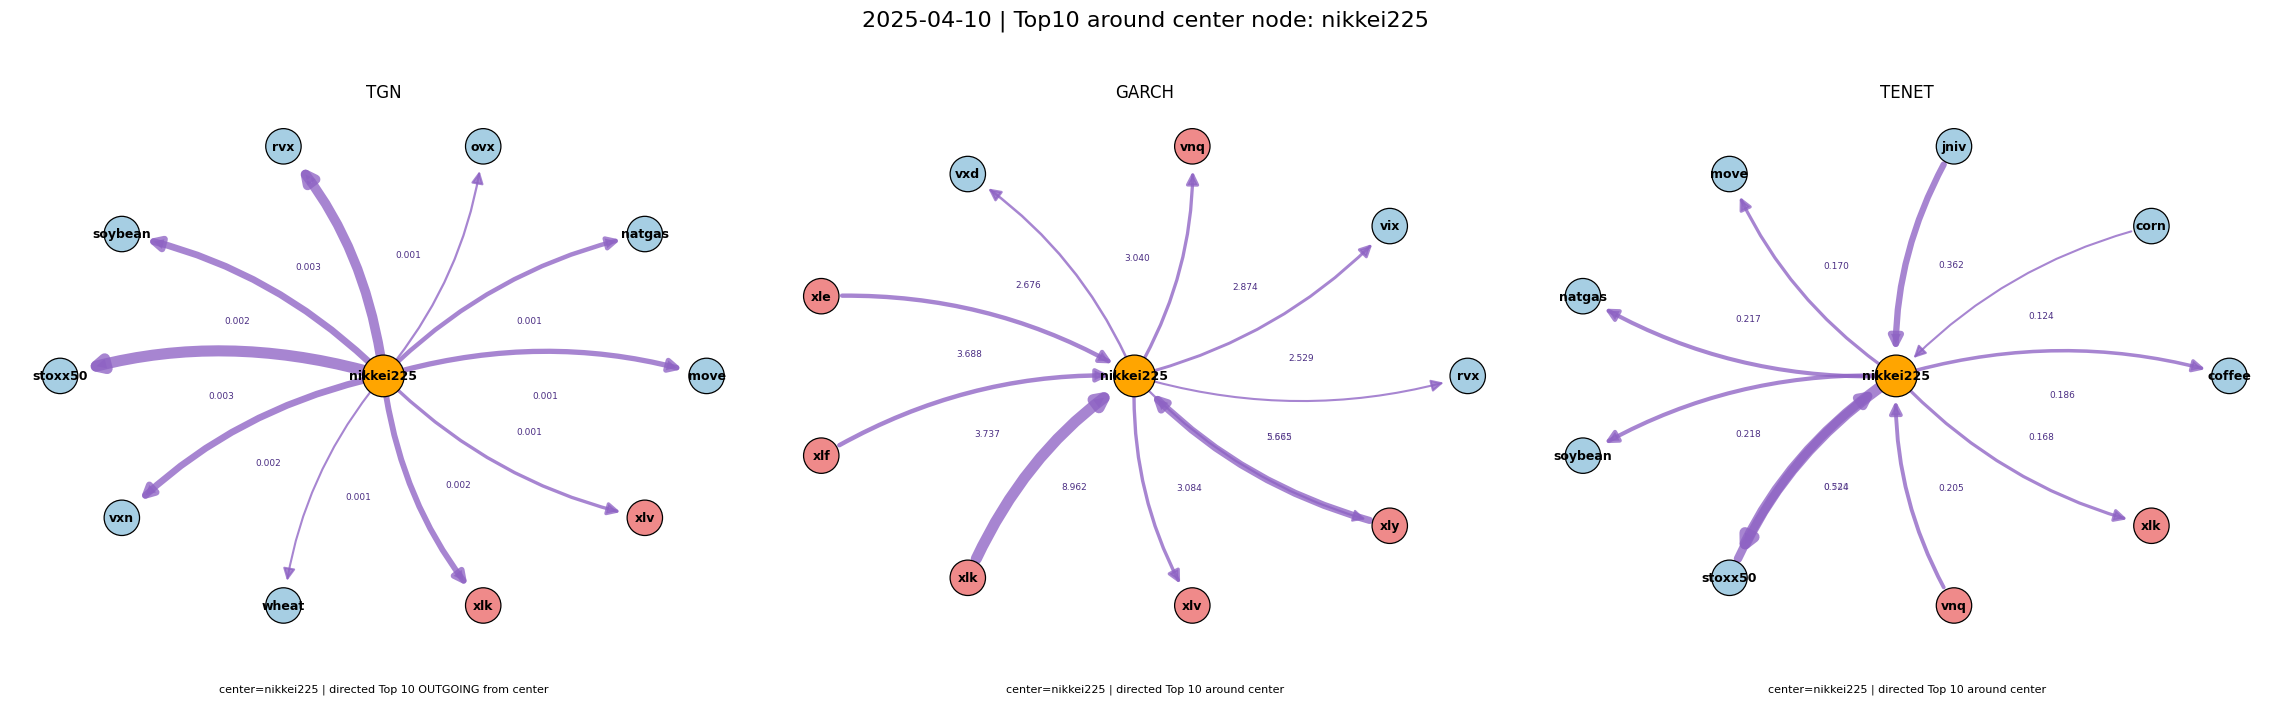

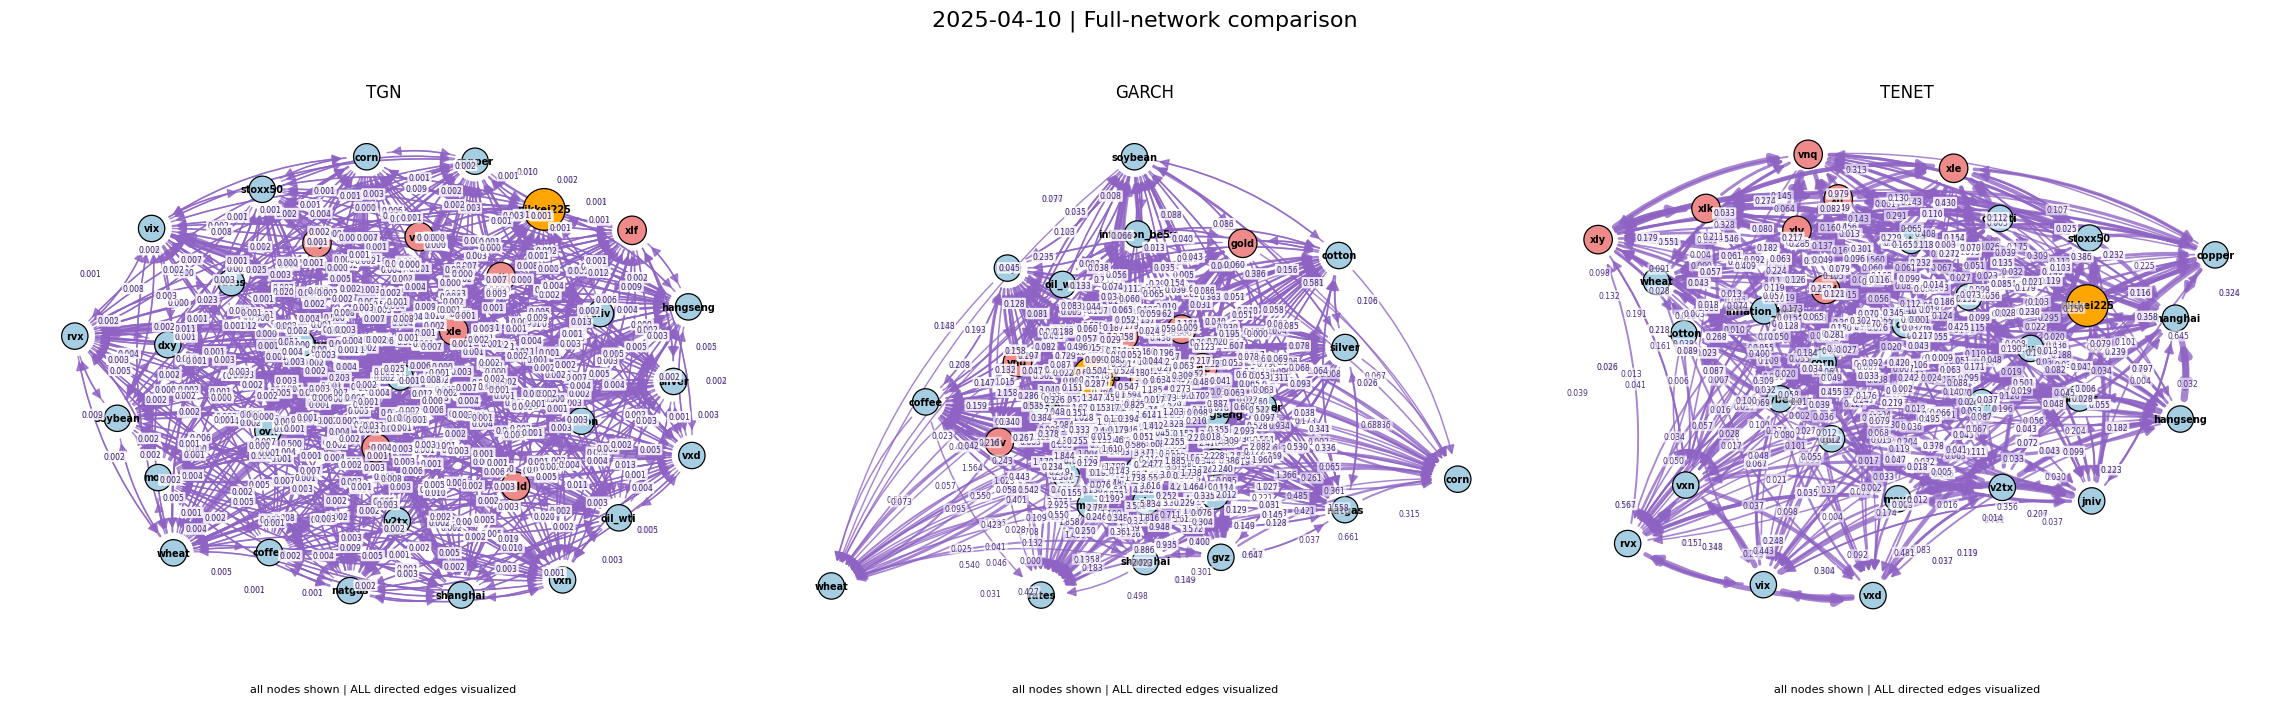


완료. 결과 파일들은 다음 폴더에 저장되었습니다:
/content/drive/MyDrive/Find-A final/network_compare_outputs


In [ ]:
import os
import glob
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

from scipy.optimize import minimize
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import QuantileRegressor

warnings.filterwarnings("ignore")

# ============================================================
# 0. 코랩(Colab) 마운트 및 기본 설정
# ============================================================
try:
    from google.colab import drive
    drive.mount('/content/drive')
    print("✅ 구글 드라이브 마운트 완료")
    PROJECT_DIR = '/content/drive/MyDrive/Find-A final'
except ImportError:
    print("⚠️ 구글 코랩 환경이 아닙니다. 로컬 경로를 사용합니다.")
    PROJECT_DIR = './Find-A final'

OUTPUT_DIR = os.path.join(PROJECT_DIR, "network_compare_outputs")
os.makedirs(OUTPUT_DIR, exist_ok=True)

# 시각화할 스냅샷 날짜 / 중심 노드 (첨부해주신 이미지와 동일한 3개)
SNAPSHOTS = [
    ("2020-03-06", "xlk"),
    ("2020-03-12", "inflation_be5y"),
    ("2025-04-10", "nikkei225"),
]

INVESTABLE_ASSETS = ["gold", "vnq", "xlk", "xlf", "xlv", "xle", "xly"]
TRAIN_END = "2018-12-31"

# TGN 설정
memory_dim = 100
time_dim = 100
msg_dim = 2
time_window = 30
rolling_window = 60
threshold = 0.001
target_col_idx = 0
num_classes = 12
TGN_MODE = "all"

# GARCH / TENET 설정
GARCH_CORR_WINDOW = 60
GARCH_MIN_TRAIN_OBS = 500
TENET_WINDOW = 60
TENET_TAU = 0.05
TENET_ALPHA = 0.005

# 시각화 설정
TOP10_PER_CENTER = 10
FIG_DPI = 220

# ============================================================
# 1. TGN 관련 import
# ============================================================
HAS_TGN_DEPS = True
try:
    import torch
    import torch.nn.functional as F
    from torch.nn import Linear
    from torch_geometric.nn.models.tgn import TGNMemory, IdentityMessage, LastAggregator
    from torch_geometric.nn import TransformerConv
except Exception as e:
    HAS_TGN_DEPS = False
    TGN_IMPORT_ERROR = e

try:
    from pyinform.transferentropy import transfer_entropy as pyinform_te
except Exception:
    pyinform_te = None

if HAS_TGN_DEPS:
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
else:
    device = "cpu"

if HAS_TGN_DEPS:
    class GraphEmbedding(torch.nn.Module):
        def __init__(self, in_channels, out_channels, msg_dim, time_dim):
            super().__init__()
            self.time_enc = Linear(1, msg_dim)
            self.conv = TransformerConv(
                in_channels=in_channels,
                out_channels=out_channels // 2,
                heads=2,
                dropout=0.1,
                edge_dim=msg_dim,
            )

        def forward(self, x, last_update, edge_index, t, msg, return_attention=False):
            rel_t = (t - last_update[edge_index[0]]).float()
            rel_t_emb = self.time_enc(rel_t.view(-1, 1))
            edge_attr = msg + rel_t_emb
            if return_attention:
                out, (edges, alpha) = self.conv(x, edge_index, edge_attr, return_attention_weights=True)
                return out, edges, alpha
            return self.conv(x, edge_index, edge_attr)

    class NodePredictor(torch.nn.Module):
        def __init__(self, embedding_dim, out_dim=12):
            super().__init__()
            self.lin1 = Linear(embedding_dim, embedding_dim // 2)
            self.lin2 = Linear(embedding_dim // 2, out_dim)

        def forward(self, target_node):
            h = self.lin1(target_node)
            h = torch.relu(h)
            return self.lin2(h)

# ============================================================
# 2. 데이터 로딩 / 전처리
# ============================================================
def _safe_read_csv(path):
    df = pd.read_csv(path)
    df.columns = df.columns.str.strip()
    rename_dict = {col: "Date" for col in df.columns if col.lower() in ["date", "날짜", "time"]}
    df.rename(columns=rename_dict, inplace=True)
    return df

def load_tgn_csv_data(project_dir):
    allowed_dirs = ["equity", "volatility", "macro", "commodities"]
    raw_data_dict = {}
    load_rows = []
    csv_files = []
    for sub in allowed_dirs:
        csv_files.extend(glob.glob(os.path.join(project_dir, sub, "*.csv")))

    for file_path in csv_files:
        asset_name = os.path.splitext(os.path.basename(file_path))[0]
        if asset_name.lower() == "manifest":
            continue
        try:
            df = _safe_read_csv(file_path)
            duplicate = asset_name in raw_data_dict
            if duplicate:
                print(f"[중복 스킵/overwrite] {asset_name}: {file_path}")
            raw_data_dict[asset_name] = df
            load_rows.append({
                "node": asset_name,
                "path": os.path.relpath(file_path, project_dir),
                "duplicate_overwrite": duplicate,
            })
        except Exception as e:
            print(f"[{asset_name}] 로드 에러: {e}")

    if "vkospi" in raw_data_dict:
        del raw_data_dict["vkospi"]
        load_rows.append({"node": "vkospi", "path": "removed", "duplicate_overwrite": False})

    pd.DataFrame(load_rows).to_csv(os.path.join(OUTPUT_DIR, "node_loading_log.csv"), index=False, encoding="utf-8-sig")
    return raw_data_dict

def preprocess_tgn_data(raw_data_dict):
    asset_names = list(raw_data_dict.keys())
    processed_data = {}
    raw_returns_history = {}

    for name in asset_names:
        df = raw_data_dict[name].copy()
        df["Date"] = pd.to_datetime(df["Date"])
        df = df.sort_values("Date").set_index("Date")
        target_col = df.columns[target_col_idx]

        if df[target_col].min() >= 0 and df[target_col].mean() > 1.0:
            df["Log_Return"] = np.log(df[target_col] / df[target_col].shift(1))
        else:
            df["Log_Return"] = df[target_col]

        raw_returns_history[name] = df["Log_Return"].copy()
        df["rolling_mean"] = df["Log_Return"].rolling(window=rolling_window).mean()
        df["rolling_std"] = df["Log_Return"].rolling(window=rolling_window).std()
        df["scaled_value"] = (df["Log_Return"] - df["rolling_mean"]) / (df["rolling_std"] + 1e-8)
        df = df.dropna()

        raw_class = np.floor(df["scaled_value"])
        df["target_class"] = (raw_class.clip(-6, 5) + 6).astype(int)
        processed_data[name] = df

    all_dates = set()
    for df in processed_data.values():
        all_dates.update(df.index)
    global_calendar = pd.Series(list(all_dates)).sort_values().reset_index(drop=True)
    returns_df = pd.DataFrame(raw_returns_history).sort_index()

    pd.DataFrame({"node_index": range(len(asset_names)), "node": asset_names}).to_csv(
        os.path.join(OUTPUT_DIR, "node_order_used.csv"), index=False, encoding="utf-8-sig"
    )
    return global_calendar, processed_data, returns_df, asset_names

# ============================================================
# 3. TGN edge / snapshot
# ============================================================
def te_score(source_discrete, target_discrete, k=1):
    if pyinform_te is not None:
        try:
            return float(pyinform_te(source_discrete.astype(int), target_discrete.astype(int), k=k))
        except Exception:
            pass
    n = len(source_discrete)
    if n <= k:
        return 0.0
    return sum(source_discrete[i - 1] == target_discrete[i] for i in range(k, n)) / (n - k)

def build_edges(current_date, processed_data, asset_names):
    bins = [-1.0, 1.0]
    active_nodes = []
    for i, name in enumerate(asset_names):
        if current_date in processed_data[name].index and not pd.isna(processed_data[name].loc[current_date, "scaled_value"]):
            active_nodes.append(i)

    edge_sources, edge_targets, edge_features = [], [], []
    for i in active_nodes:
        name_i = asset_names[i]
        current_return = processed_data[name_i].loc[current_date, "scaled_value"]
        edge_sources.append(i)
        edge_targets.append(i)
        edge_features.append([current_return, 1.0])

        data_i = processed_data[name_i].loc[:current_date, "scaled_value"].tail(time_window).values
        for j in active_nodes:
            if i == j:
                continue
            name_j = asset_names[j]
            data_j = processed_data[name_j].loc[:current_date, "scaled_value"].tail(time_window).values
            if len(data_i) == time_window and len(data_j) == time_window:
                source_discrete = np.digitize(data_i, bins)
                target_discrete = np.digitize(data_j, bins)
                score = te_score(source_discrete, target_discrete, k=1)
                if score >= threshold:
                    edge_sources.append(i)
                    edge_targets.append(j)
                    edge_features.append([current_return, score])

    if len(edge_sources) == 0:
        edge_index = torch.empty((2, 0), dtype=torch.long).to(device)
        edge_attr = torch.empty((0, msg_dim), dtype=torch.float).to(device)
    else:
        edge_index = torch.tensor([edge_sources, edge_targets], dtype=torch.long).to(device)
        edge_attr = torch.tensor(edge_features, dtype=torch.float).to(device)
    return active_nodes, edge_index, edge_attr

def load_tgn_models(mode, num_asset):
    memory = TGNMemory(
        num_nodes=num_asset,
        raw_msg_dim=msg_dim,
        memory_dim=memory_dim,
        time_dim=time_dim,
        message_module=IdentityMessage(msg_dim, memory_dim, time_dim),
        aggregator_module=LastAggregator(),
    ).to(device)
    gnn = GraphEmbedding(memory_dim, memory_dim, msg_dim, time_dim).to(device)
    predictor = NodePredictor(embedding_dim=memory_dim, out_dim=num_classes).to(device)

    memory.load_state_dict(torch.load(os.path.join(PROJECT_DIR, f"best_memory_{mode}.pth"), map_location=device))
    gnn.load_state_dict(torch.load(os.path.join(PROJECT_DIR, f"best_gnn_{mode}.pth"), map_location=device))
    predictor.load_state_dict(torch.load(os.path.join(PROJECT_DIR, f"best_predictor_{mode}.pth"), map_location=device))
    memory.eval(); gnn.eval(); predictor.eval()
    return memory, gnn, predictor

def resolve_to_calendar_date(target_date, global_calendar):
    td = pd.to_datetime(target_date)
    cal = pd.to_datetime(global_calendar)
    if td in set(cal):
        return td
    prev = cal[cal <= td]
    if len(prev) == 0:
        raise ValueError(f"{target_date} 이전에 사용 가능한 캘린더 날짜가 없습니다.")
    resolved = prev.max()
    print(f"[날짜 조정] {target_date} -> {resolved.date()} (가장 가까운 이전 거래일)")
    return resolved

def get_tgn_snapshot_edges(snapshot_date, global_calendar, processed_data, asset_names, mode=TGN_MODE):
    if not HAS_TGN_DEPS:
        raise RuntimeError(f"TGN 의존 패키지가 없습니다: {repr(TGN_IMPORT_ERROR)}")

    snapshot_date = resolve_to_calendar_date(snapshot_date, global_calendar)
    num_asset = len(asset_names)
    all_nodes_tensor = torch.arange(num_asset, dtype=torch.long).to(device)
    memory, gnn, predictor = load_tgn_models(mode, num_asset)
    memory.reset_state()

    idx_map = {pd.to_datetime(d): i for i, d in enumerate(global_calendar)}
    target_idx = idx_map[snapshot_date]
    if target_idx < time_window:
        raise ValueError("snapshot_date가 너무 이릅니다.")

    snapshot_edges_df = None
    with torch.no_grad():
        for t_idx in range(time_window, target_idx + 1):
            current_date = pd.to_datetime(global_calendar[t_idx])
            active_nodes, edge_index, edge_attr = build_edges(current_date, processed_data, asset_names)
            if len(active_nodes) == 0 or edge_index.size(1) == 0:
                continue

            t_tensor = torch.full((edge_index.size(1),), t_idx, dtype=torch.long).to(device)
            z, last_update = memory(all_nodes_tensor)

            if current_date == snapshot_date:
                _, edges_used, alpha = gnn(z, last_update, edge_index, t_tensor, edge_attr, return_attention=True)
                attn = alpha.mean(dim=1).detach().cpu().numpy() if alpha.ndim == 2 else alpha.detach().cpu().numpy()
                e = edges_used.detach().cpu().numpy()
                rows = []
                for k in range(e.shape[1]):
                    src = asset_names[int(e[0, k])]
                    tgt = asset_names[int(e[1, k])]
                    if src == tgt:
                        continue
                    rows.append({
                        "date": snapshot_date.strftime("%Y-%m-%d"),
                        "source": src,
                        "target": tgt,
                        "weight": float(attn[k]),
                        "model": "TGN",
                    })
                snapshot_edges_df = pd.DataFrame(rows).sort_values("weight", ascending=False).reset_index(drop=True)
                break

            memory.update_state(edge_index[0], edge_index[1], t_tensor, edge_attr)

    if snapshot_edges_df is None:
        raise ValueError(f"TGN snapshot을 {snapshot_date.date()} 에서 추출하지 못했습니다.")
    return snapshot_edges_df, snapshot_date

# ============================================================
# 4. GARCH all-node snapshot
# ============================================================
def garch_negloglike(params, eps):
    omega, alpha, beta = params
    if omega <= 0 or alpha < 0 or beta < 0 or alpha + beta >= 0.999:
        return 1e12
    n = len(eps)
    h = np.empty(n)
    h[0] = np.var(eps) + 1e-8
    for t in range(1, n):
        h[t] = omega + alpha * eps[t - 1] ** 2 + beta * h[t - 1]
        if h[t] <= 1e-12 or not np.isfinite(h[t]):
            return 1e12
    return 0.5 * np.sum(np.log(2 * np.pi) + np.log(h) + eps ** 2 / h)

def fit_garch11(train_returns):
    r = pd.Series(train_returns).dropna().astype(float)
    if len(r) < GARCH_MIN_TRAIN_OBS:
        raise ValueError(f"GARCH 학습 데이터가 너무 적습니다: {len(r)}")
    mu = r.mean()
    eps = (r - mu).values
    var = np.var(eps) + 1e-8
    x0 = np.array([0.05 * var, 0.08, 0.90])
    bounds = [(1e-10, 10 * var + 1e-8), (1e-6, 0.5), (1e-6, 0.999)]
    cons = ({"type": "ineq", "fun": lambda x: 0.999 - x[1] - x[2]})
    res = minimize(garch_negloglike, x0=x0, args=(eps,), method="SLSQP", bounds=bounds, constraints=cons, options={"maxiter": 500})
    if not res.success:
        omega, alpha, beta = x0
    else:
        omega, alpha, beta = res.x
    return {"mu": mu, "omega": omega, "alpha": alpha, "beta": beta}

def garch_conditional_vol(full_returns, params):
    r = pd.Series(full_returns).dropna().astype(float)
    eps = (r - params["mu"]).values
    h = np.empty(len(eps))
    h[0] = np.var(eps) + 1e-8
    omega, alpha, beta = params["omega"], params["alpha"], params["beta"]
    for t in range(1, len(eps)):
        h[t] = omega + alpha * eps[t - 1] ** 2 + beta * h[t - 1]
        if h[t] <= 1e-12 or not np.isfinite(h[t]):
            h[t] = np.nan
    return pd.Series(np.sqrt(h), index=r.index, name=r.name)

def prepare_garch_allnode(returns_df):
    returns = returns_df.sort_index().copy()
    train_mask = returns.index <= pd.to_datetime(TRAIN_END)
    train_returns = returns.loc[train_mask]

    params = {}
    vol_df = pd.DataFrame(index=returns.index)
    for node in returns.columns:
        r_train = train_returns[node].dropna()
        if len(r_train) < GARCH_MIN_TRAIN_OBS:
            continue
        p = fit_garch11(r_train)
        params[node] = p
        vol_df[node] = garch_conditional_vol(returns[node], p)
        print("GARCH fitted:", node)

    common_nodes = [c for c in returns.columns if c in vol_df.columns]
    returns = returns[common_nodes].copy()
    vol_df = vol_df[common_nodes].copy()
    train_vol = vol_df.loc[train_mask]
    vol_z = (vol_df - train_vol.mean()) / (train_vol.std() + 1e-8)
    return returns, vol_df, vol_z

def get_garch_snapshot_edges(snapshot_date, returns_all, vol_z_all):
    snapshot_date = pd.to_datetime(snapshot_date)
    available_dates = returns_all.index[returns_all.index <= snapshot_date]
    if len(available_dates) == 0:
        raise ValueError(f"{snapshot_date.date()} 이전 GARCH 데이터가 없습니다.")
    d = available_dates.max()

    rows = []
    cols = returns_all.columns.tolist()
    for src in cols:
        for tgt in cols:
            if src == tgt:
                continue
            lag_corr_series = returns_all[src].shift(1).rolling(GARCH_CORR_WINDOW, min_periods=30).corr(returns_all[tgt])
            if d not in lag_corr_series.index or d not in vol_z_all.index:
                continue
            lag_corr = lag_corr_series.loc[d]
            zv = vol_z_all.loc[d, src] if src in vol_z_all.columns else np.nan
            if pd.isna(lag_corr) or pd.isna(zv):
                continue
            score = max(float(zv), 0.0) * abs(float(lag_corr))
            if score <= 0:
                continue
            rows.append({
                "date": d.strftime("%Y-%m-%d"),
                "source": src,
                "target": tgt,
                "weight": float(score),
                "lag_corr": float(lag_corr),
                "source_vol_z": float(zv),
                "model": "GARCH",
            })
    edge_df = pd.DataFrame(rows).sort_values("weight", ascending=False).reset_index(drop=True)
    return edge_df, d

# ============================================================
# 5. TENET snapshot
# ============================================================
def analyze_tenet_risk(df_returns, tau=0.05, alpha_penalty=0.005):
    asset_names = df_returns.columns.tolist()
    scaler = StandardScaler()
    df_scaled = pd.DataFrame(scaler.fit_transform(df_returns), columns=asset_names, index=df_returns.index)
    adj_matrix = pd.DataFrame(0.0, index=asset_names, columns=asset_names)

    for target_asset in asset_names:
        y = df_scaled[target_asset]
        X = df_scaled.drop(columns=[target_asset])
        qr = QuantileRegressor(quantile=tau, alpha=alpha_penalty, solver='highs')
        qr.fit(X, y)
        for i, feature_asset in enumerate(X.columns):
            adj_matrix.loc[feature_asset, target_asset] = np.abs(qr.coef_[i])

    G = nx.DiGraph()
    for emitter in asset_names:
        for receiver in asset_names:
            weight = adj_matrix.loc[emitter, receiver]
            if weight > 0.0 and emitter != receiver:
                G.add_edge(emitter, receiver, weight=float(weight))
    return G, adj_matrix

def get_tenet_snapshot_edges(snapshot_date, returns_df):
    snapshot_date = pd.to_datetime(snapshot_date)
    available_dates = returns_df.index[returns_df.index <= snapshot_date]
    if len(available_dates) == 0:
        raise ValueError(f"{snapshot_date.date()} 이전 TENET 데이터가 없습니다.")
    d = available_dates.max()
    window_df = returns_df.loc[:d].tail(TENET_WINDOW).dropna(axis=1, how="any").dropna(axis=0, how="any")

    if len(window_df) < 20:
        raise ValueError(f"TENET 윈도우 데이터가 너무 적습니다: {len(window_df)}")

    G, adj = analyze_tenet_risk(window_df, tau=TENET_TAU, alpha_penalty=TENET_ALPHA)
    rows = []
    for u, v, data in G.edges(data=True):
        rows.append({
            "date": d.strftime("%Y-%m-%d"),
            "source": u,
            "target": v,
            "weight": float(data["weight"]),
            "model": "TENET",
        })
    edge_df = pd.DataFrame(rows).sort_values("weight", ascending=False).reset_index(drop=True)
    return edge_df, d

# ============================================================
# 6. 시각화 유틸
# ============================================================
def normalize_node_name(name):
    return str(name).lower().strip()

def top_center_edges(edge_df, center, topk=10, is_tgn=False):
    center = normalize_node_name(center)
    if is_tgn:
        # TGN은 중심 노드에서 '나가는' (source == center) 엣지만 필터링
        sub = edge_df[edge_df["source"].str.lower() == center].copy()
    else:
        # 다른 모델은 들어오고 나가는 양방향 모두 포함
        sub = edge_df[(edge_df["source"].str.lower() == center) | (edge_df["target"].str.lower() == center)].copy()

    sub = sub.sort_values("weight", ascending=False).head(topk).reset_index(drop=True)
    return sub

def build_positions_for_topcenter(edge_df, center):
    center = normalize_node_name(center)
    nodes = sorted(set(edge_df["source"]).union(edge_df["target"]))
    others = [n for n in nodes if normalize_node_name(n) != center]
    pos = {center: np.array([0.0, 0.0])}
    if len(others) == 0:
        return pos
    angles = np.linspace(0, 2*np.pi, len(others), endpoint=False)
    radius = 1.0
    for ang, n in zip(angles, others):
        pos[n] = np.array([radius * np.cos(ang), radius * np.sin(ang)])
    return pos

def build_positions_for_full(all_nodes, edge_df, seed=42):
    G = nx.DiGraph()
    G.add_nodes_from(all_nodes)
    for _, r in edge_df.iterrows():
        G.add_edge(r["source"], r["target"], weight=float(r["weight"]))
    UG = nx.Graph()
    UG.add_nodes_from(G.nodes())
    for u, v, data in G.edges(data=True):
        w = float(data.get("weight", 1.0))
        if UG.has_edge(u, v):
            UG[u][v]["weight"] += w
        else:
            UG.add_edge(u, v, weight=w)
    pos = nx.spring_layout(UG, seed=seed, k=1.2/np.sqrt(max(1, len(all_nodes))))
    return pos

def scale_widths(weights, min_w=1.0, max_w=7.0):
    weights = np.asarray(weights, dtype=float)
    if len(weights) == 0:
        return np.array([])
    if np.nanmax(weights) <= np.nanmin(weights):
        return np.full(len(weights), (min_w + max_w) / 2)
    scaled = (weights - np.nanmin(weights)) / (np.nanmax(weights) - np.nanmin(weights) + 1e-12)
    return min_w + (max_w - min_w) * (scaled ** 0.8)

def draw_directed_graph(ax, edge_df, title, all_nodes=None, center=None, topcenter=False, note=None):
    ax.set_title(title, fontsize=12, pad=10)
    if edge_df is None or len(edge_df) == 0:
        ax.text(0.5, 0.5, "No edges", ha="center", va="center", fontsize=12)
        ax.axis("off")
        return

    if all_nodes is None:
        nodes = sorted(set(edge_df["source"]).union(edge_df["target"]))
    else:
        nodes = list(all_nodes)

    if topcenter and center is not None:
        nodes = sorted(set(edge_df["source"]).union(edge_df["target"]))
        if center not in nodes:
            nodes = [center] + nodes
        pos = build_positions_for_topcenter(edge_df, center)
    else:
        pos = build_positions_for_full(nodes, edge_df, seed=42)

    G = nx.DiGraph()
    G.add_nodes_from(nodes)
    for _, r in edge_df.iterrows():
        G.add_edge(r["source"], r["target"], weight=float(r["weight"]))

    node_colors = []
    node_sizes = []
    for n in G.nodes():
        if center is not None and normalize_node_name(n) == normalize_node_name(center):
            node_colors.append("orange")
            node_sizes.append(900)
        elif normalize_node_name(n) in [a.lower() for a in INVESTABLE_ASSETS]:
            node_colors.append("#ef8a8a")
            node_sizes.append(650 if topcenter else 420)
        else:
            node_colors.append("#a6cee3")
            node_sizes.append(650 if topcenter else 360)

    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes, edgecolors="black", linewidths=0.9, ax=ax)
    nx.draw_networkx_labels(G, pos, font_size=9 if topcenter else 7, font_weight="bold", ax=ax)

    edge_list = list(G.edges(data=True))
    weights = [float(d["weight"]) for _, _, d in edge_list]
    widths = scale_widths(weights, min_w=1.0 if not topcenter else 1.5, max_w=6.0 if not topcenter else 8.0)

    for idx, (u, v, data) in enumerate(edge_list):
        # 모든 선에 대해 일관된 곡률(rad)을 적용하여 시각적 통일성 확보
        rad = 0.15 if str(u) < str(v) else -0.15

        nx.draw_networkx_edges(
            G, pos,
            edgelist=[(u, v)],
            arrowstyle='-|>',
            arrowsize=18 if topcenter else 14,
            width=float(widths[idx]),
            edge_color="#8e63c4",
            alpha=0.78,
            connectionstyle=f"arc3,rad={rad}",
            ax=ax,
            min_source_margin=15,
            min_target_margin=18,
        )

        x1, y1 = pos[u]
        x2, y2 = pos[v]
        mx, my = (x1 + x2) / 2, (y1 + y2) / 2

        # 곡률에 맞게 라벨 위치 오프셋 조정
        dx, dy = x2 - x1, y2 - y1
        norm = np.sqrt(dx*dx + dy*dy) + 1e-12
        px, py = -dy / norm, dx / norm
        shift = 0.08 if rad > 0 else -0.08
        mx += shift * px
        my += shift * py

        ax.text(mx, my, f"{float(data['weight']):.3f}", fontsize=6.5 if topcenter else 5.5,
                color="#4b2e83", ha="center", va="center",
                bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.6))

    if note:
        ax.text(0.5, -0.08, note, transform=ax.transAxes, ha="center", va="top", fontsize=8)
    ax.axis("off")

def save_edge_csv(edge_df, out_path):
    edge_df.to_csv(out_path, index=False, encoding="utf-8-sig")

def make_comparison_figure(date_str, center, view_type,
                           tgn_edges, garch_edges, tenet_edges,
                           all_nodes, csv_prefix):
    fig, axes = plt.subplots(1, 3, figsize=(23, 7.4))

    if view_type == "top10":
        # TGN의 경우 중심 노드에서 '나가는' 엣지만 필터링 (is_tgn=True)
        tgn_sub = top_center_edges(tgn_edges, center, TOP10_PER_CENTER, is_tgn=True)
        garch_sub = top_center_edges(garch_edges, center, TOP10_PER_CENTER, is_tgn=False)
        tenet_sub = top_center_edges(tenet_edges, center, TOP10_PER_CENTER, is_tgn=False)

        note_tgn = f"center={center} | directed Top {TOP10_PER_CENTER} OUTGOING from center"
        note_other = f"center={center} | directed Top {TOP10_PER_CENTER} around center"

        draw_directed_graph(axes[0], tgn_sub, "TGN", center=center, topcenter=True, note=note_tgn)
        draw_directed_graph(axes[1], garch_sub, "GARCH", center=center, topcenter=True, note=note_other)
        draw_directed_graph(axes[2], tenet_sub, "TENET", center=center, topcenter=True, note=note_other)

        save_edge_csv(tgn_sub, f"{csv_prefix}_TGN_edges.csv")
        save_edge_csv(garch_sub, f"{csv_prefix}_GARCH_edges.csv")
        save_edge_csv(tenet_sub, f"{csv_prefix}_TENET_edges.csv")
        fig.suptitle(f"{date_str} | Top10 around center node: {center}", fontsize=16, y=0.98)
    else:
        # 전체 네트워크 시각화 시 어떠한 상위 컷(Top K)도 적용하지 않음. 즉 전체 연결을 모두 보여줌
        tgn_sub = tgn_edges.sort_values("weight", ascending=False).reset_index(drop=True)
        garch_sub = garch_edges.sort_values("weight", ascending=False).reset_index(drop=True)
        tenet_sub = tenet_edges.sort_values("weight", ascending=False).reset_index(drop=True)

        note = "all nodes shown | ALL directed edges visualized"

        draw_directed_graph(axes[0], tgn_sub, "TGN", all_nodes=all_nodes, center=center, topcenter=False, note=note)
        draw_directed_graph(axes[1], garch_sub, "GARCH", all_nodes=all_nodes, center=center, topcenter=False, note=note)
        draw_directed_graph(axes[2], tenet_sub, "TENET", all_nodes=all_nodes, center=center, topcenter=False, note=note)

        save_edge_csv(tgn_sub, f"{csv_prefix}_TGN_edges.csv")
        save_edge_csv(garch_sub, f"{csv_prefix}_GARCH_edges.csv")
        save_edge_csv(tenet_sub, f"{csv_prefix}_TENET_edges.csv")
        fig.suptitle(f"{date_str} | Full-network comparison", fontsize=16, y=0.98)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()  # <--- 화면에 그림을 바로 띄워주도록 수정 (저장 후 닫기 삭제)

# ============================================================
# 7. 메인 실행
# ============================================================
def main():
    raw_data_dict = load_tgn_csv_data(PROJECT_DIR)
    global_calendar, processed_data, returns_df, asset_names = preprocess_tgn_data(raw_data_dict)
    print("Nodes:", len(asset_names), asset_names)
    print("Return history:", returns_df.shape, returns_df.index.min(), "~", returns_df.index.max())

    returns_all = returns_df[asset_names].sort_index().replace([np.inf, -np.inf], np.nan)
    returns_all = returns_all.ffill().dropna(how="any")
    all_nodes = list(returns_all.columns)
    print("All-node returns used for GARCH/TENET:", returns_all.shape)

    garch_ret, garch_vol, garch_vol_z = prepare_garch_allnode(returns_all)

    summary_rows = []

    for date_str, center in SNAPSHOTS:
        print("\n" + "="*70)
        print("snapshot:", date_str, "center:", center)

        tgn_edges, tgn_used_date = get_tgn_snapshot_edges(date_str, global_calendar, processed_data, asset_names, mode=TGN_MODE)
        garch_edges, garch_used_date = get_garch_snapshot_edges(date_str, garch_ret, garch_vol_z)
        tenet_edges, tenet_used_date = get_tenet_snapshot_edges(date_str, returns_all)

        used_date_str = max([tgn_used_date, garch_used_date, tenet_used_date]).strftime("%Y-%m-%d")
        summary_rows.append({
            "requested_date": date_str,
            "center": center,
            "tgn_used_date": tgn_used_date.strftime("%Y-%m-%d"),
            "garch_used_date": garch_used_date.strftime("%Y-%m-%d"),
            "tenet_used_date": tenet_used_date.strftime("%Y-%m-%d"),
        })

        tgn_edges.to_csv(os.path.join(OUTPUT_DIR, f"{date_str}_{center}_TGN_all_edges_raw.csv"), index=False, encoding="utf-8-sig")
        garch_edges.to_csv(os.path.join(OUTPUT_DIR, f"{date_str}_{center}_GARCH_all_edges_raw.csv"), index=False, encoding="utf-8-sig")
        tenet_edges.to_csv(os.path.join(OUTPUT_DIR, f"{date_str}_{center}_TENET_all_edges_raw.csv"), index=False, encoding="utf-8-sig")

        top_prefix = os.path.join(OUTPUT_DIR, f"compare_{date_str}_{center}_top10")
        full_prefix = os.path.join(OUTPUT_DIR, f"compare_{date_str}_{center}_full")

        make_comparison_figure(date_str, center, "top10", tgn_edges, garch_edges, tenet_edges, all_nodes, top_prefix)
        make_comparison_figure(date_str, center, "full", tgn_edges, garch_edges, tenet_edges, all_nodes, full_prefix)

    pd.DataFrame(summary_rows).to_csv(os.path.join(OUTPUT_DIR, "snapshot_used_dates_summary.csv"), index=False, encoding="utf-8-sig")
    print("\n완료. 결과 파일들은 다음 폴더에 저장되었습니다:")
    print(OUTPUT_DIR)

if __name__ == "__main__":
    main()